In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# load the titanic the dataset using seaborn
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [5]:
from sklearn.impute import SimpleImputer

In [6]:
df.drop(['deck'], inplace=True, axis=1)

In [7]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [9]:
df.age.fillna(df.age.median(), inplace=True)

/tmp/ipykernel_1756/3104992794.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.age.fillna(df.age.median(), inplace=True)


In [10]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [11]:
df.embark_town.fillna(df.embark_town.mode()[0], inplace=True)

/tmp/ipykernel_1756/3607455960.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.embark_town.fillna(df.embark_town.mode()[0], inplace=True)


In [12]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [13]:
df.drop(['embarked'], inplace=True, axis=1)

In [14]:
df

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


In [15]:
print(df.corr(numeric_only=True))

            survived    pclass       age     sibsp     parch      fare  \
survived    1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307   
pclass     -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500   
age        -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688   
sibsp      -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651   
parch       0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225   
fare        0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000   
adult_male -0.557080  0.094035  0.247704 -0.253586 -0.349943 -0.182024   
alone      -0.203367  0.135207  0.171647 -0.584471 -0.583398 -0.271832   

            adult_male     alone  
survived     -0.557080 -0.203367  
pclass        0.094035  0.135207  
age           0.247704  0.171647  
sibsp        -0.253586 -0.584471  
parch        -0.349943 -0.583398  
fare         -0.182024 -0.271832  
adult_male    1.000000  0.404744  
alone         0.404744  1.000000  


In [16]:
X = df.drop(['survived'], axis=1)
y = df.survived

In [17]:
X

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,1,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,3,female,28.0,1,2,23.4500,Third,woman,False,Southampton,no,False
889,1,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


In [18]:
y

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [19]:
from sklearn.pipeline import Pipeline

In [20]:
numeric_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(exclude=np.number).columns

In [21]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [22]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [23]:
from sklearn.compose import ColumnTransformer

In [24]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [25]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean','manhattan']
}

In [28]:
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

In [29]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['sex', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone'], dtype='object'))])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__metric': ['euclidean', 'manhattan'],
                         'classifier__n_neighbors': [3, 5, 7, 9],
                         'classifier__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [30]:
grid_search.best_params_

{'classifier__metric': 'manhattan',
 'classifier__n_neighbors': 5,
 'classifier__weights': 'distance'}

In [31]:
train_accuracy = grid_search.best_score_

In [32]:
y_pred = grid_search.predict(X_test)

In [33]:
pred_accuracy = accuracy_score(y_test, y_pred)

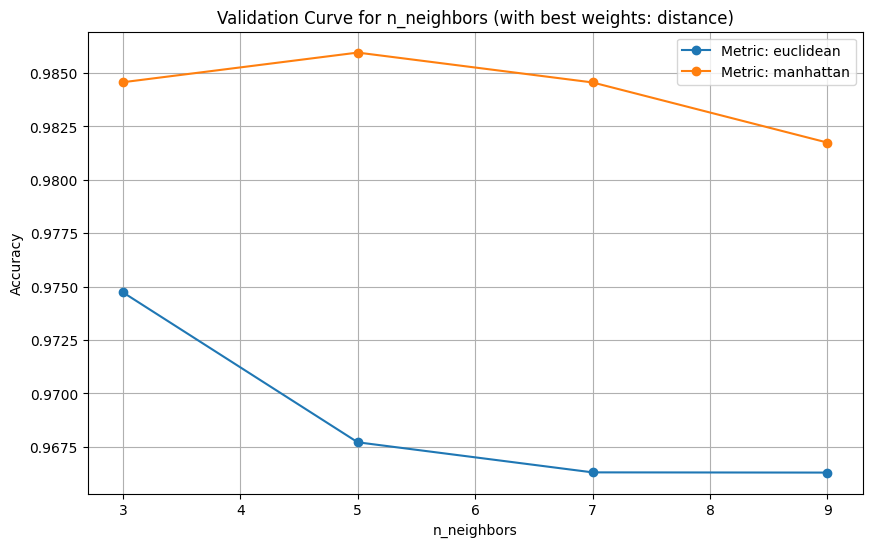

In [34]:
import pandas as pd

plt.figure(figsize=(10, 6))

results = pd.DataFrame(grid_search.cv_results_)
best_weights_val = grid_search.best_params_['classifier__weights']

# Get all unique metric values from param_grid
metric_values = param_grid['classifier__metric']

for metric in metric_values:
    filtered_results = results[
        (results['param_classifier__metric'] == metric) &
        (results['param_classifier__weights'] == best_weights_val)
    ].sort_values(by='param_classifier__n_neighbors') # Sort to ensure correct plotting order

    n_neighbors_values = filtered_results['param_classifier__n_neighbors'].values
    mean_test_scores = filtered_results['mean_test_score'].values

    plt.plot(n_neighbors_values, mean_test_scores, marker='o', label=f'Metric: {metric}')

plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title(f'Validation Curve for n_neighbors (with best weights: {best_weights_val})')
plt.grid(True)
plt.legend()
plt.show()

# Validating the Hypothesis


In [35]:
Titanic_df = sns.load_dataset('titanic')
Titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [36]:
Titanic_df.dropna(inplace=True, axis=0)

In [37]:
Titanic_df.drop(['deck', 'embark_town'], inplace=True, axis=1)

In [38]:
Titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,yes,True


In [39]:
X1 = Titanic_df.drop(['survived'], axis=1)
y1 = Titanic_df.survived

In [40]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [41]:
X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape

((145, 12), (37, 12), (145,), (37,))

In [42]:
Scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore')

In [43]:
X1_train_num = X1_train.select_dtypes(include=np.number).dropna()
X1_train_cat = X1_train.select_dtypes(exclude=np.number).dropna()

In [44]:
X1_train_num = Scaler.fit_transform(X1_train_num)

In [45]:
X1_train_cat = encoder.fit_transform(X1_train_cat).toarray()

In [46]:
X1_train_cat

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 1.],
       [1., 0., 1., ..., 1., 1., 0.],
       [0., 1., 0., ..., 1., 0., 1.]])

In [47]:
X1_train_num

array([[-3.95490531e-01,  6.68156463e-01, -7.26758825e-01,
        -6.15744023e-01, -6.27023571e-01],
       [-3.95490531e-01, -4.28252548e-01,  8.00487981e-01,
        -6.15744023e-01, -1.51418854e-01],
       [ 1.45438453e+00, -2.15592735e+00,  8.00487981e-01,
         6.97239555e-01, -6.58231229e-01],
       [ 3.30425960e+00, -6.94048671e-01, -7.26758825e-01,
        -6.15744023e-01, -8.87295444e-01],
       [-3.95490531e-01,  1.03339700e-01,  8.00487981e-01,
         6.97239555e-01, -3.26753466e-01],
       [-3.95490531e-01,  1.69811644e+00, -7.26758825e-01,
        -6.15744023e-01, -5.79328282e-01],
       [ 1.45438453e+00, -8.26946733e-01, -7.26758825e-01,
        -6.15744023e-01, -8.10628213e-01],
       [-3.95490531e-01,  1.16652419e+00,  2.32773479e+00,
        -6.15744023e-01, -3.40172759e-01],
       [-3.95490531e-01,  1.89746353e+00,  8.00487981e-01,
         4.63619029e+00,  2.30025481e+00],
       [-3.95490531e-01,  2.36237762e-01,  8.00487981e-01,
         6.97239555e-01

In [48]:
model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='manhattan')

In [49]:
train_data = np.concatenate((X1_train_num, X1_train_cat), axis=1)

In [50]:
model.fit(train_data, y1_train)

KNeighborsClassifier(metric='manhattan', weights='distance')

In [51]:
X1_test_num = X1_test.select_dtypes(include=np.number).dropna()
X1_test_cat = X1_test.select_dtypes(exclude=np.number).dropna()

In [52]:
X1_test_num = Scaler.transform(X1_test_num)

In [53]:
X1_test_cat = encoder.transform(X1_test_cat).toarray()

In [54]:
test_data = np.concatenate((X1_test_num, X1_test_cat), axis=1)

In [55]:
y_pred = model.predict(test_data)

In [56]:
accuracy_score(y1_test, y_pred)

0.9459459459459459

In [57]:
model1 = KNeighborsClassifier(n_neighbors=7, weights='uniform', metric='euclidean')

In [58]:
model1.fit(train_data, y1_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7)

In [59]:
ypred = model1.predict(test_data)

In [60]:
accuracy_score(y1_test, ypred)

0.9459459459459459

In [61]:
# Export the model
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(model1, open('model1.pkl', 'wb'))
pickle.dump(Scaler, open('Scaler.pkl', 'wb'))
pickle.dump(encoder, open('encoder.pkl', 'wb'))
pickle.dump(grid_search, open('grid_search.pkl', 'wb'))
pickle.dump(param_grid, open('param_grid.pkl', 'wb'))
pickle.dump(preprocessor, open('preprocessor.pkl', 'wb'))